## Setup

In [1]:
#import of libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/penguins.csv") # gets data from source file

# body measurements used throughout the analysis
measurements = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

## 1. Data Quality

# 1.1 First Look at the Data

In [2]:
df.head() # shows head + first 5 rows of data for a quick overview

,rowid,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


not all rows contain measurements or sex
lenght in mm 
weight in g
. as a separator

In [3]:
df.info() # number of not empty values, data types, ...

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              344 non-null    int64  
 1   species            344 non-null    str    
 2   island             344 non-null    str    
 3   bill_length_mm     342 non-null    float64
 4   bill_depth_mm      342 non-null    float64
 5   flipper_length_mm  342 non-null    float64
 6   body_mass_g        342 non-null    float64
 7   sex                333 non-null    str    
 8   year               344 non-null    int64  
dtypes: float64(4), int64(2), str(3)
memory usage: 24.3 KB


measurements (#3 to #6) each miss 2 values
sex misses 11 values
other columns are complete

In [4]:
df.isna().sum() # shows sum of n/a values

rowid                 0
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

missing values: sex (11), bill_length_mm (2), bill_depth_mm (2), flipper_length_mm (2), body_mass_g (2)

In [5]:
df.duplicated().sum() # shows sum of duplicate rows of data

np.int64(0)

0 = no duplicates --> good, no further action needed

# 1.2 Looking at rows with missing values

In [6]:
df[df.isna().any(axis=1)] # shows rows with missing values n/a

,rowid,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
8,9,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN,2007
9,10,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN,2007
10,11,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN,2007
11,12,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN,2007
47,48,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN,2007
178,179,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN,2007
218,219,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN,2008
256,257,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN,2009
268,269,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN,2009


# 1.3 Decision & Clean-up

Decision: We drop the 2 rows with missing measurements (4 and 272). The sex column also has missing values. Dropping them all would cost us 11 rows, so we keep sex = NaN rows for the body-measurement analysis and only filter by sex where needed.

In [7]:
df_clean = df.dropna(subset=measurements) # writes cleaned data in a new data frame, leaving the original df as is | only drops rows were measurements are na
print(f"Original: {len(df)} rows → nach dropna(subset=...): {len(df_clean)} rows")# writes out the difference in number of rows

Original: 344 rows → nach dropna(subset=...): 342 rows


In [8]:
sex_missing = df_clean["sex"].isna().sum() # new variable that contains the sum of rows where sex is na
print(f"Rows kept with missing 'sex': {sex_missing}") # writes out how many rows have na sex

Rows kept with missing 'sex': 9


In [9]:
df_clean.dtypes # checking data types

rowid                  int64
species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
year                   int64
dtype: object

data types are fine, no action needed

## 2. Univariate Analysis: Distributions of Measurements

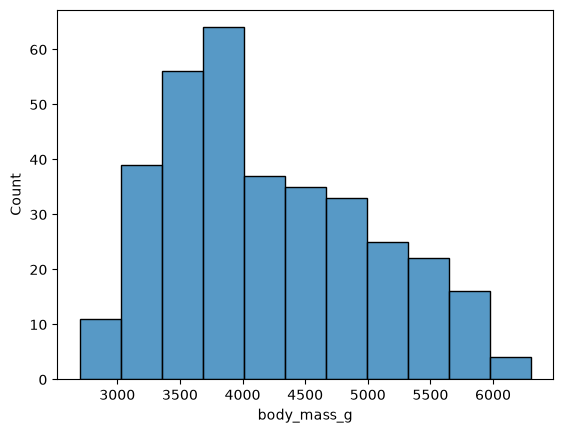

In [ ]:
# body mass first
sns.histplot(data=df_clean, x="body_mass_g")
plt.show()

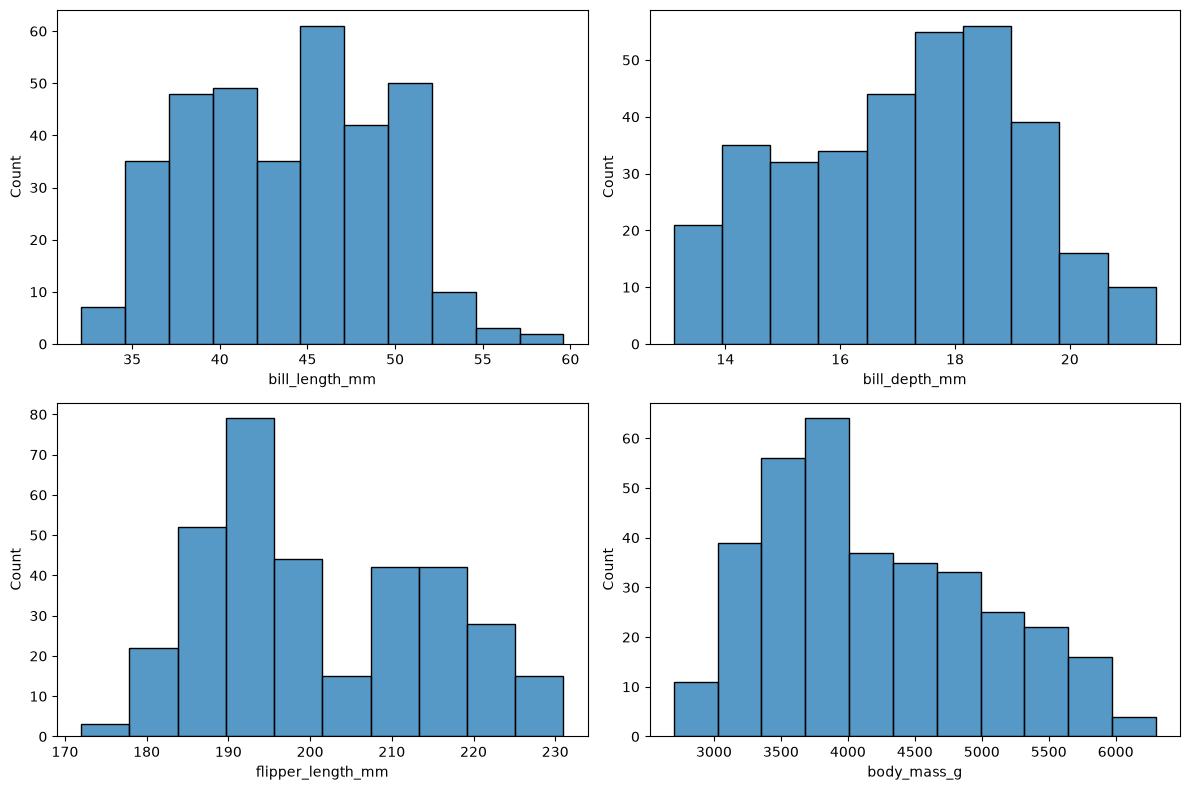

In [ ]:
# 2x2 grid: one histogram per measurement, all measurements compared side by side
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# zip pairs each plot area (ax) with its column (col)
for ax, col in zip(axes.flat, measurements):
    sns.histplot(data=df_clean, x=col, ax=ax)

plt.tight_layout()  # prevent overlapping axis labels
plt.show()

- body mass is closest to a normal distribution/bell shape
- other 3 measurements all have multiple peaks
- body mass has a big range (~2.7–6.3 kg)
- multiple peaks suggest underlying groups (possibly different species)

